# Protein Function Prediction with Sequence and AlphaFold Structure Features

**Training and evaluation report**

This notebook reconstructs the repository pipeline for Gene Ontology (GO) term
prediction from protein amino acid sequences, then summarizes the controlled
sequence-vs-structure comparison implemented in the project.

The central research question is:

> Does adding AlphaFold-derived structural information improve protein function
> prediction compared with sequence-only models when the dataset, split, label
> vocabulary, and evaluation protocol are held fixed?

The notebook avoids inventing results. If a raw data file, prediction bundle, or
metric artifact is absent, the relevant section reports the missing artifact and
states what would be needed to complete that analysis.


## How to Run

Run this notebook from the repository root.

The notebook uses repository-local summary tables under `output/` and, when
available, full training artifacts from `CAFA5_ARTIFACT_ROOT`. On the Savio
project environment it also checks the known scratch artifact root. To make
the full-artifact location explicit, set:

```bash
export CAFA5_ARTIFACT_ROOT=/global/scratch/users/bensonli/cafa5_outputs
```

If full artifacts are not found, the notebook will still run and will use any
available repo-local summary tables. Sections that require full prediction
bundles will display a missing-artifact note instead of fabricating plots.


In [1]:
from __future__ import annotations

import json
import math
import os
from collections import Counter
from pathlib import Path
from typing import Any

os.environ.setdefault("MPLCONFIGDIR", "/tmp/matplotlib-cafa5-report")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch
from IPython.display import Markdown, display

try:
    import pyarrow.compute as pc
    import pyarrow.parquet as pq
    HAVE_PYARROW = True
except Exception:
    HAVE_PYARROW = False

PROJECT_ROOT = Path.cwd()
LOCAL_OUTPUT = PROJECT_ROOT / "output"
REPORT_ASSETS = LOCAL_OUTPUT / "jupyter-notebook" / "report_assets"
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

artifact_root_env = os.environ.get("CAFA5_ARTIFACT_ROOT")
artifact_candidates = [
    Path(artifact_root_env).expanduser() if artifact_root_env else None,
    Path("/global/scratch/users/bensonli/cafa5_outputs"),
    PROJECT_ROOT / "outputs",
    PROJECT_ROOT / "output",
]
def has_full_artifact_layout(path: Path | None) -> bool:
    if path is None or not path.exists():
        return False
    return (path / "manifests" / "training_index.parquet").exists() or (path / "graph_cache" / "metadata" / "entries.json").exists()
ARTIFACT_ROOT = next((p for p in artifact_candidates if has_full_artifact_layout(p)), None)

GRAPH_ROOT = ARTIFACT_ROOT / "graph_cache" if ARTIFACT_ROOT else PROJECT_ROOT / "output" / "graph_cache"
MANIFEST_DIR = ARTIFACT_ROOT / "manifests" if ARTIFACT_ROOT else PROJECT_ROOT / "output" / "manifests"
FEATURE_DIR = ARTIFACT_ROOT / "features" if ARTIFACT_ROOT else PROJECT_ROOT / "output" / "features"
SEQUENCE_RUN_ROOT = ARTIFACT_ROOT / "sequence_runs" if ARTIFACT_ROOT else PROJECT_ROOT / "output" / "sequence_runs"
FUSION_ROOT = ARTIFACT_ROOT / "n4_fusion" if ARTIFACT_ROOT else PROJECT_ROOT / "output" / "n4_fusion"

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({
    "figure.figsize": (8, 4.8),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.frameon": False,
})



MODEL_COLORS = {
    "Sequence-only ESM2 MLP": "#4C78A8",
    "Structure-enhanced graph": "#F28E2B",
    "Val-selected fusion": "#59A14F",
    "Raw graph baseline": "#7A7A7A",
    "Weighted BCE": "#B07AA1",
    "Label-aware scorer": "#E15759",
    "Label-aware scorer, longer confirmation": "#D62728",
    "k-mer": "#9C755F",
    "ESM2": "#4C78A8",
}

def clean_axis(ax) -> None:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="y", alpha=0.25)
    ax.grid(axis="x", alpha=0.12)

def label_bars(ax, fmt: str = "{:.3f}", orient: str = "v", pad: float = 0.003) -> None:
    for patch in ax.patches:
        if orient == "h":
            value = patch.get_width()
            x = value + (pad if value >= 0 else -pad)
            y = patch.get_y() + patch.get_height() / 2
            ha = "left" if value >= 0 else "right"
            ax.text(x, y, fmt.format(value), va="center", ha=ha, fontsize=9)
        else:
            value = patch.get_height()
            x = patch.get_x() + patch.get_width() / 2
            y = value + pad
            ax.text(x, y, fmt.format(value), va="bottom", ha="center", fontsize=9)

def set_zoom_ylim(ax, values, margin: float = 0.004, floor: float | None = None) -> None:
    vals = pd.Series(values).dropna().astype(float)
    if vals.empty:
        return
    low = vals.min() - margin
    high = vals.max() + margin
    if floor is not None:
        low = max(floor, low)
    if math.isclose(low, high):
        low -= margin
        high += margin
    ax.set_ylim(low, high)

def set_zoom_xlim(ax, values, margin: float = 0.004, floor: float | None = None) -> None:
    vals = pd.Series(values).dropna().astype(float)
    if vals.empty:
        return
    low = vals.min() - margin
    high = vals.max() + margin
    if floor is not None:
        low = max(floor, low)
    if math.isclose(low, high):
        low -= margin
        high += margin
    ax.set_xlim(low, high)

def as_pp(value: float) -> float:
    return 100.0 * float(value)

def note(message: str, level: str = "info") -> None:
    color = {"info": "#eef6ff", "warn": "#fff5df", "error": "#ffecec"}.get(level, "#eef6ff")
    border = {"info": "#5b8fd8", "warn": "#d99b20", "error": "#d85b5b"}.get(level, "#5b8fd8")
    display(Markdown(
        f"<div style='background:{color}; border-left:4px solid {border}; padding:0.75rem 1rem;'>"
        f"{message}</div>"
    ))

def read_json(path: Path) -> Any | None:
    if not path.exists():
        return None
    with path.open("r", encoding="utf-8") as handle:
        return json.load(handle)

def read_lines(path: Path) -> list[str]:
    if not path.exists():
        return []
    return [line.strip() for line in path.read_text(encoding="utf-8").splitlines() if line.strip()]

def safe_read_csv(path: Path, **kwargs) -> pd.DataFrame:
    if not path.exists():
        note(f"Missing table: `{path}`", "warn")
        return pd.DataFrame()
    return pd.read_csv(path, **kwargs)

def display_df(df: pd.DataFrame, caption: str | None = None, max_rows: int = 12) -> None:
    if caption:
        display(Markdown(f"**{caption}**"))
    if df.empty:
        note("No rows available for this table.", "warn")
    else:
        display(df.head(max_rows))

summary = {
    "project_root": str(PROJECT_ROOT),
    "local_output_exists": LOCAL_OUTPUT.exists(),
    "report_assets_exists": REPORT_ASSETS.exists(),
    "artifact_root": str(ARTIFACT_ROOT) if ARTIFACT_ROOT else "not found",
    "graph_root_exists": GRAPH_ROOT.exists(),
    "manifest_dir_exists": MANIFEST_DIR.exists(),
}
display_df(pd.DataFrame([summary]), "Detected artifact roots")


**Detected artifact roots**

,project_root,local_output_exists,report_assets_exists,artifact_root,graph_root_exists,manifest_dir_exists
0,/global/home/users/bensonli/c242_cafa5,True,True,/global/scratch/users/bensonli/cafa5_outputs,True,True


## 0. Repository Understanding

The repository is organized around a single protein-function prediction system
with sequence-only and structure-enhanced branches. The controlled comparison
uses the same structure-available cohort, GO aspect split, label vocabulary, and
evaluation metrics wherever the needed artifacts exist.

**Main pipeline components found in the repository**

| Component | Files | Role |
| --- | --- | --- |
| AlphaFold acquisition | `cafa5_alphafold_pipeline.py`, `alphafold_downloader.py` | Read CAFA5 sequence and annotation files, query AlphaFold DB by UniProt accession, download PDB/PAE artifacts, write parquet manifests. |
| Structure feature extraction | `alphafold_feature_extractor.py` | Convert AlphaFold PDB/PAE files into fragment features, residue features, and contact-graph edge features. |
| Graph cache and datasets | `cafa_graph_dataset.py`, `build_cafa_graph_cache.py` | Build per-protein graph tensors and expose PyG/DGL datasets with a stable 682-dimensional node schema. |
| Deterministic splits and loaders | `cafa_graph_dataloaders.py`, `export_graph_dataloaders.py` | Export train/validation/test manifests per GO aspect and construct PyG/DGL dataloaders. |
| Optional modality caches | `cafa_multimodal_cache_builders.py`, `build_esm2_cache.py`, `build_structure_cache.py` | Add residue-level ESM2 embeddings and DSSP/SASA features without changing graph cache API. |
| Graph training | `train_minimal_graph_model.py`, `scripts/savio_train_full_graph.sh`, `scripts/savio_train_full_graph_tuned.sh` | Train multi-label graph classifiers with BCE variants, Fmax selection, early stopping, and optional label-aware heads. |
| Sequence matched baseline | `export_sequence_artifacts_from_graph_cache.py`, `train_sequence_esm_from_graph_cache.py` | Mirror graph splits and train sequence-only classifiers from protein-level ESM2 embeddings on the matched cohort. |
| Prediction export and fusion | `export_graph_prediction_bundles.py`, `fuse_prediction_scores.py` | Export comparable score bundles and combine sequence/graph scores for late-fusion experiments. |
| Tests | `tests/` | Unit tests for preprocessing, graph datasets/loaders, training, sequence artifact export, and fusion. |
| Reports and artifacts | `docs/`, `output/jupyter-notebook/report_assets/`, scratch `training_runs/` | Experiment plans, progress summaries, extracted CSV result tables, checkpoints, logs, and run summaries. |

**Baseline pipeline:** sequence-only classifiers over protein-level ESM2 features
exported from graph-cache-aligned sequence artifacts.

**Structure-enhanced pipeline:** AlphaFold-derived residue contact graphs with
amino-acid identity, pLDDT, PAE, contact topology, graph-level structural
summaries, and optional ESM2/DSSP/SASA overlay features.


In [2]:
repo_map = pd.DataFrame([
    ["Training scripts", "train_minimal_graph_model.py; train_sequence_esm_from_graph_cache.py; scripts/savio_train_full_graph*.sh"],
    ["Preprocessing", "cafa5_alphafold_pipeline.py; alphafold_feature_extractor.py; build_cafa_graph_cache.py; export_sequence_artifacts_from_graph_cache.py"],
    ["Model definitions", "MinimalPygClassifier, MinimalDglClassifier, SequenceLinearClassifier, SequenceMlpClassifier"],
    ["Feature extraction", "AlphaFold PDB/PAE -> residue, edge, fragment parquets; ESM2/DSSP/SASA cache builders"],
    ["Configuration", "CLI arguments, Savio shell scripts, run_config.json, summary.json, requirements-*.txt"],
    ["Evaluation", "Fmax, micro/macro precision/recall/F1 in train_minimal_graph_model.py; fusion evaluation in fuse_prediction_scores.py"],
    ["Logs/checkpoints", "training_runs/*/{train.log,best.pt,summary.json,results_summary.json}; *.out/*.err Slurm logs"],
    ["Results", "output/jupyter-notebook/report_assets/*.csv; docs/*progress*; n4_fusion/*/summary.tsv"],
], columns=["Repository area", "Observed files or artifacts"])
display_df(repo_map, "Repository map", max_rows=20)


**Repository map**

,Repository area,Observed files or artifacts
0,Training scripts,train_minimal_graph_model.py; train_sequence_e...
1,Preprocessing,cafa5_alphafold_pipeline.py; alphafold_feature...
2,Model definitions,"MinimalPygClassifier, MinimalDglClassifier, Se..."
3,Feature extraction,"AlphaFold PDB/PAE -> residue, edge, fragment p..."
4,Configuration,"CLI arguments, Savio shell scripts, run_config..."
5,Evaluation,"Fmax, micro/macro precision/recall/F1 in train..."
6,Logs/checkpoints,"training_runs/*/{train.log,best.pt,summary.jso..."
7,Results,output/jupyter-notebook/report_assets/*.csv; d...


## 1. Project Overview

Protein function prediction maps an amino acid sequence to a set of GO terms.
This is a multi-label classification task: one protein can have many valid GO
annotations, and the output is a vector of probabilities over a large GO label
vocabulary.

Key challenges:

- **Long sequences:** many proteins have hundreds to thousands of residues.
- **Large label space:** the complete CAFA5 label matrix has tens of thousands
  of possible GO terms.
- **Class imbalance:** most GO terms are rare, so macro metrics and rare-label
  behavior matter.
- **GO hierarchy:** GO terms are not independent, but the implemented primary
  training objective treats labels as independent binary targets, with an
  optional ontology regularizer in the label-aware branch.

The extension in this repository incorporates AlphaFold-derived structure. The
intended experimental control is to keep the cohort, train/validation/test split,
label vocabulary, and metrics fixed while changing the input representation from
sequence-only to sequence plus structural features.


## 2. Dataset and Label Space

This section computes dataset and label summaries from the available artifacts.
When the full training manifest is available, the notebook uses
`manifests/training_index.parquet`. When only repo-local summary tables are
available, it falls back to the split and result CSV files under
`output/jupyter-notebook/report_assets/`.


In [3]:
training_index_path = MANIFEST_DIR / "training_index.parquet"
fragment_features_path = FEATURE_DIR / "fragment_features.parquet"
entries_path = GRAPH_ROOT / "metadata" / "entries.json"
term_counts_path = GRAPH_ROOT / "metadata" / "term_counts.json"
schema_path = GRAPH_ROOT / "metadata" / "schema.json"
split_overview_path = REPORT_ASSETS / "graph_split_overview.csv"

dataset_summary: dict[str, Any] = {}
sequence_lengths = pd.Series(dtype=float)
labels_per_protein = pd.Series(dtype=float)
ontology_counts = pd.Series(dtype=float)
term_counts_by_aspect: dict[str, Counter] = {}

def as_term_list(value: Any) -> list[str]:
    """Normalize list-like GO term cells loaded from pandas/pyarrow."""
    if value is None:
        return []
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (list, tuple, set)):
        return list(value)
    return []

if HAVE_PYARROW and training_index_path.exists():
    table = pq.read_table(
        training_index_path,
        columns=["sequence_length", "go_terms_bpo", "go_terms_cco", "go_terms_mfo", "af_status"],
    )
    df_manifest = table.to_pandas()
    sequence_lengths = df_manifest["sequence_length"].dropna().astype(int)
    for aspect, col in {"BPO": "go_terms_bpo", "CCO": "go_terms_cco", "MFO": "go_terms_mfo"}.items():
        counts = Counter(term for terms in df_manifest[col] for term in as_term_list(terms))
        term_counts_by_aspect[aspect] = counts
    labels_per_protein = df_manifest[["go_terms_bpo", "go_terms_cco", "go_terms_mfo"]].apply(
        lambda row: sum(len(as_term_list(value)) for value in row), axis=1
    )
    ontology_counts = pd.Series({aspect: sum(counts.values()) for aspect, counts in term_counts_by_aspect.items()})
    dataset_summary.update({
        "training_manifest_rows": int(len(df_manifest)),
        "alphafold_ok_rows": int((df_manifest["af_status"] == "ok").sum()),
        "alphafold_ok_fraction": float((df_manifest["af_status"] == "ok").mean()),
        "median_sequence_length": float(sequence_lengths.median()),
        "mean_labels_per_protein": float(labels_per_protein.mean()),
        "unique_go_terms_raw": int(len(set().union(*[set(c.keys()) for c in term_counts_by_aspect.values()]))),
    })
else:
    note("Full `training_index.parquet` is not available or `pyarrow` is missing. Raw sequence and raw-label plots will use any available graph metadata instead.", "warn")

metadata_term_counts = read_json(term_counts_path) or {}
if metadata_term_counts:
    term_counts_by_aspect = {
        aspect: Counter({term: int(count) for term, count in counts.items()})
        for aspect, counts in metadata_term_counts.items()
    }

split_overview = safe_read_csv(split_overview_path)
if not split_overview.empty:
    for _, row in split_overview.iterrows():
        dataset_summary[f"{row['aspect']}_matched_proteins"] = int(row["proteins"])
        dataset_summary[f"{row['aspect']}_labels_mtf20"] = int(row["labels"])

schema = read_json(schema_path) or {}
dataset_summary.update({
    "graph_entries": len(read_json(entries_path) or []) if entries_path.exists() else None,
    "node_feature_dim": schema.get("node_feature_dim"),
    "edge_attr_dim": schema.get("edge_attr_dim"),
    "graph_feat_dim": schema.get("graph_feat_dim"),
})

display_df(pd.DataFrame([dataset_summary]), "Dataset summary")


**Dataset summary**

,training_manifest_rows,alphafold_ok_rows,alphafold_ok_fraction,median_sequence_length,mean_labels_per_protein,unique_go_terms_raw,CCO_matched_proteins,CCO_labels_mtf20,MFO_matched_proteins,MFO_labels_mtf20,BPO_matched_proteins,BPO_labels_mtf20,graph_entries,node_feature_dim,edge_attr_dim,graph_feat_dim
0,142246,122925,0.864172,411.0,37.708357,31466,82610,1025,73021,1521,80741,7665,122924,682,6,13


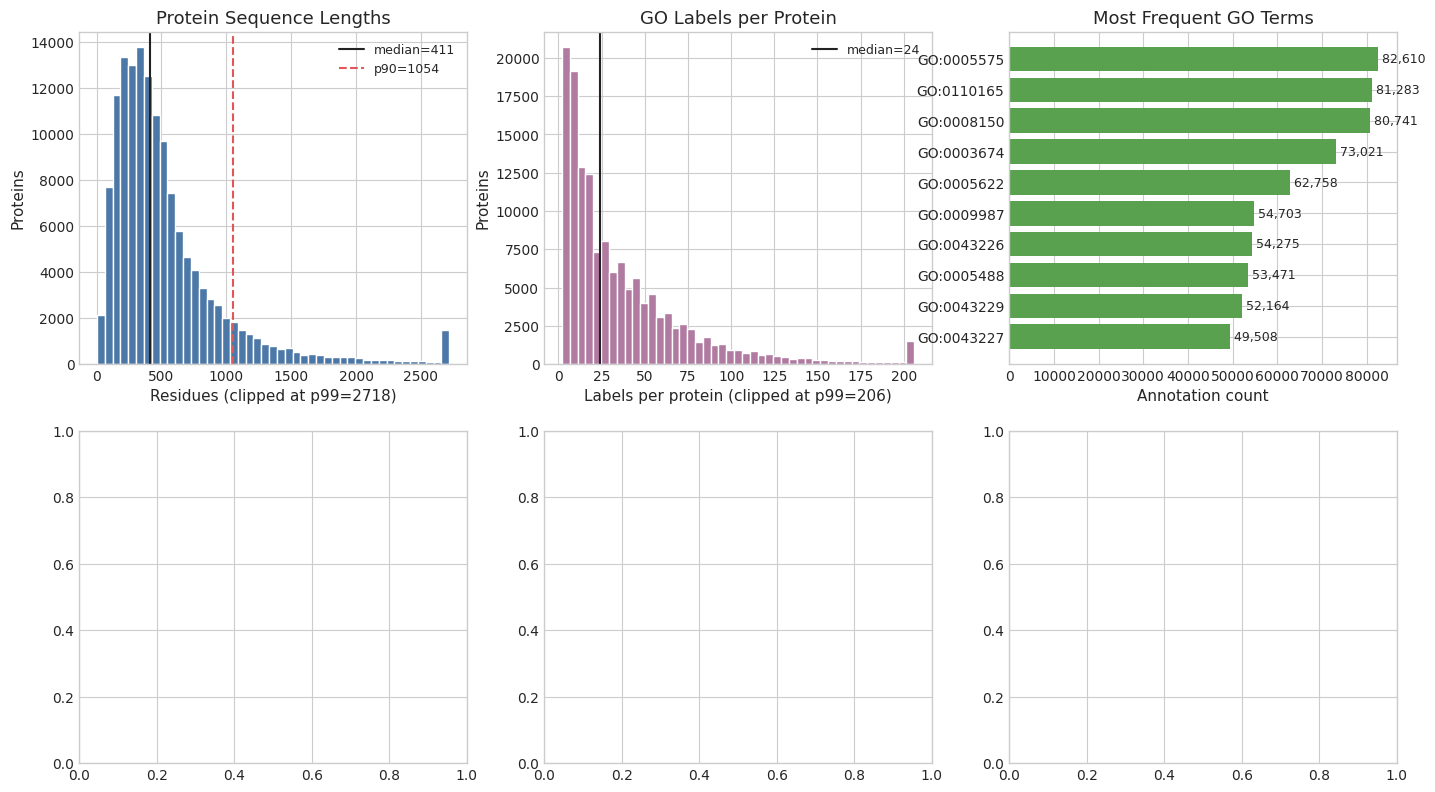

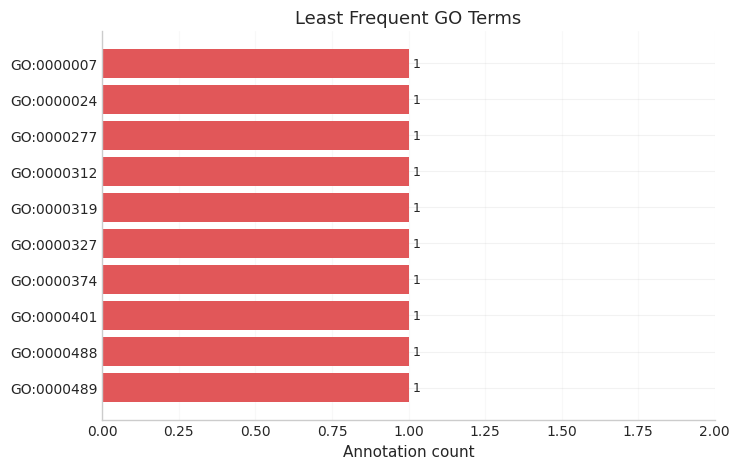

<Figure size 800x480 with 0 Axes>

<div style='background:#eef6ff; border-left:4px solid #5b8fd8; padding:0.75rem 1rem;'>Interpretation: the label space is both large and long-tailed. The later graph comparisons therefore use aspect-specific vocabularies and validation-selected Fmax rather than raw accuracy.</div>

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(17, 9.5))
axes = axes.ravel()

if not sequence_lengths.empty:
    clip_max = int(sequence_lengths.quantile(0.99))
    lengths_clip = sequence_lengths.clip(upper=clip_max)
    axes[0].hist(lengths_clip, bins=45, color="#4C78A8", edgecolor="white")
    median_len = sequence_lengths.median()
    p90_len = sequence_lengths.quantile(0.90)
    axes[0].axvline(median_len, color="#222222", lw=1.5, label=f"median={median_len:.0f}")
    axes[0].axvline(p90_len, color="#E15759", lw=1.5, linestyle="--", label=f"p90={p90_len:.0f}")
    axes[0].set_title("Protein Sequence Lengths")
    axes[0].set_xlabel(f"Residues (clipped at p99={clip_max})")
    axes[0].set_ylabel("Proteins")
    axes[0].legend(fontsize=9)
else:
    axes[0].text(0.5, 0.5, "Sequence lengths unavailable", ha="center", va="center")
    axes[0].set_axis_off()

if not labels_per_protein.empty:
    clip_labels = int(labels_per_protein.quantile(0.99))
    labels_clip = labels_per_protein.clip(upper=clip_labels)
    axes[1].hist(labels_clip, bins=45, color="#B07AA1", edgecolor="white")
    axes[1].axvline(labels_per_protein.median(), color="#222222", lw=1.5, label=f"median={labels_per_protein.median():.0f}")
    axes[1].set_title("GO Labels per Protein")
    axes[1].set_xlabel(f"Labels per protein (clipped at p99={clip_labels})")
    axes[1].set_ylabel("Proteins")
    axes[1].legend(fontsize=9)
else:
    axes[1].text(0.5, 0.5, "Per-protein labels unavailable", ha="center", va="center")
    axes[1].set_axis_off()

all_terms = Counter()
for counts in term_counts_by_aspect.values():
    all_terms.update(counts)

if all_terms:
    top_terms = pd.DataFrame(all_terms.most_common(10), columns=["GO term", "Frequency"])
    axes[2].barh(top_terms["GO term"][::-1], top_terms["Frequency"][::-1], color="#59A14F")
    axes[2].set_title("Most Frequent GO Terms")
    axes[2].set_xlabel("Annotation count")
    axes[2].set_ylabel("")
    for y, v in enumerate(top_terms["Frequency"][::-1]):
        axes[2].text(v, y, f" {int(v):,}", va="center", fontsize=9)

    rare_terms = pd.DataFrame(sorted(all_terms.items(), key=lambda item: (item[1], item[0]))[:10], columns=["GO term", "Frequency"])
    fig_rare, ax_rare = plt.subplots(figsize=(7.5, 4.8))
    ax_rare.barh(rare_terms["GO term"][::-1], rare_terms["Frequency"][::-1], color="#E15759")
    ax_rare.set_title("Least Frequent GO Terms")
    ax_rare.set_xlabel("Annotation count")
    ax_rare.set_ylabel("")
    for y, v in enumerate(rare_terms["Frequency"][::-1]):
        ax_rare.text(v, y, f" {int(v):,}", va="center", fontsize=9)
    ax_rare.set_xlim(0, max(2, rare_terms["Frequency"].max() + 1))
    clean_axis(ax_rare)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "least_frequent_go_terms.png", dpi=180, bbox_inches="tight")
    plt.show()

    freqs = np.array(sorted(all_terms.values(), reverse=True), dtype=float)
    ranks = np.arange(1, len(freqs) + 1)
    axes[3].plot(ranks, freqs, color="#F28E2B", lw=2)
    axes[3].set_xscale("log")
    axes[3].set_yscale("log")
    axes[3].set_title("GO Frequency Long Tail")
    axes[3].set_xlabel("GO term rank (log scale)")
    axes[3].set_ylabel("Annotation count (log scale)")
else:
    for ax in axes[2:4]:
        ax.text(0.5, 0.5, "Term counts unavailable", ha="center", va="center")
        ax.set_axis_off()

if term_counts_by_aspect:
    aspect_term_counts = pd.Series({aspect: len(counts) for aspect, counts in term_counts_by_aspect.items()}).sort_index()
    colors = ["#E15759", "#76B7B2", "#EDC948"][:len(aspect_term_counts)]
    axes[4].bar(aspect_term_counts.index, aspect_term_counts.values, color=colors)
    axes[4].set_title("GO Vocabulary by Ontology")
    axes[4].set_xlabel("GO aspect")
    axes[4].set_ylabel("Unique GO terms")
    label_bars(axes[4], fmt="{:.0f}", orient="v", pad=max(aspect_term_counts.max() * 0.015, 1))
else:
    axes[4].text(0.5, 0.5, "Ontology counts unavailable", ha="center", va="center")
    axes[4].set_axis_off()

if not split_overview.empty:
    split_plot = split_overview.set_index("aspect")[["train", "validation", "test"]]
    split_plot.plot(kind="bar", stacked=True, ax=axes[5], color=["#4C78A8", "#F28E2B", "#59A14F"])
    axes[5].set_title("Matched Structure Cohort Splits")
    axes[5].set_xlabel("GO aspect")
    axes[5].set_ylabel("Proteins")
    for x, (_, row) in enumerate(split_plot.iterrows()):
        axes[5].text(x, row.sum(), f"{int(row.sum()):,}", ha="center", va="bottom", fontsize=9)
    axes[5].legend(title="Split", fontsize=9)
else:
    axes[5].text(0.5, 0.5, "Split overview unavailable", ha="center", va="center")
    axes[5].set_axis_off()

for ax in axes:
    if ax.has_data():
        clean_axis(ax)

plt.tight_layout()
plt.savefig(FIGURE_DIR / "dataset_label_space_summary.png", dpi=180, bbox_inches="tight")
plt.show()

note("Interpretation: the label space is both large and long-tailed. The later graph comparisons therefore use aspect-specific vocabularies and validation-selected Fmax rather than raw accuracy.", "info")

## 3. Data Preprocessing Pipeline

The preprocessing pipeline converts raw CAFA5 sequence and annotation files into
matched sequence and graph artifacts.

1. **Raw data loading:** `cafa5_alphafold_pipeline.py` reads CAFA5 taxonomy,
   FASTA sequence, and GO term TSV files.
2. **AlphaFold matching:** UniProt accessions are queried against AlphaFold DB.
   Successful entries receive downloaded PDB and PAE files.
3. **Structure feature extraction:** `alphafold_feature_extractor.py` parses CA
   atoms and PAE matrices, aligns AlphaFold residues back to CAFA sequence
   positions, and writes residue, edge, and fragment parquet tables.
4. **Graph cache materialization:** `cafa_graph_dataset.py` builds per-protein
   graph tensors with node features, edge features, graph-level features, and
   multi-label GO targets.
5. **Split export:** `cafa_graph_dataloaders.py` writes deterministic 80/10/10
   train/validation/test splits per GO aspect.
6. **Sequence artifacts:** `export_sequence_artifacts_from_graph_cache.py`
   mirrors the same graph splits and exports protein-level ESM2 matrices for
   a matched sequence-only baseline.

This keeps the comparison controlled: the sequence-only and structure-enhanced
models can be evaluated on the same proteins, labels, and splits.


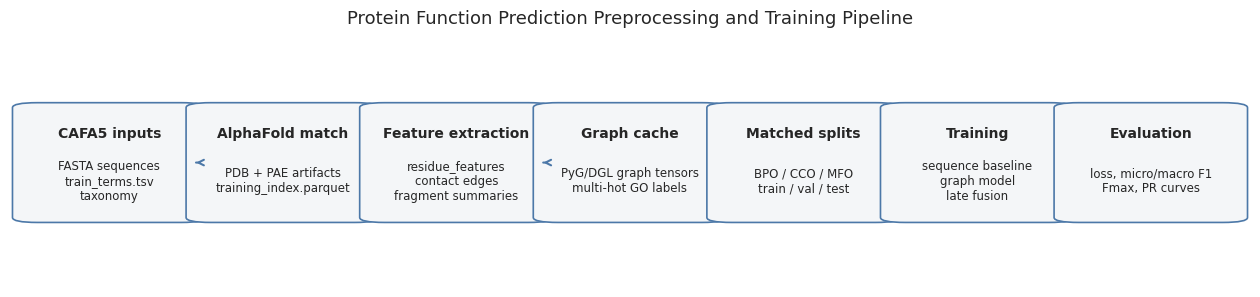

In [5]:
def draw_pipeline_diagram() -> None:
    steps = [
        ("CAFA5 inputs", "FASTA sequences\ntrain_terms.tsv\ntaxonomy"),
        ("AlphaFold match", "PDB + PAE artifacts\ntraining_index.parquet"),
        ("Feature extraction", "residue_features\ncontact edges\nfragment summaries"),
        ("Graph cache", "PyG/DGL graph tensors\nmulti-hot GO labels"),
        ("Matched splits", "BPO / CCO / MFO\ntrain / val / test"),
        ("Training", "sequence baseline\ngraph model\nlate fusion"),
        ("Evaluation", "loss, micro/macro F1\nFmax, PR curves"),
    ]
    fig, ax = plt.subplots(figsize=(16, 3.2))
    ax.set_axis_off()
    x_positions = np.linspace(0.02, 0.86, len(steps))
    for idx, ((title, body), x) in enumerate(zip(steps, x_positions)):
        box = FancyBboxPatch(
            (x, 0.28), 0.12, 0.45,
            boxstyle="round,pad=0.018,rounding_size=0.02",
            linewidth=1.2,
            facecolor="#F4F6F8",
            edgecolor="#4C78A8",
            transform=ax.transAxes,
        )
        ax.add_patch(box)
        ax.text(x + 0.06, 0.62, title, ha="center", va="center", fontsize=10, weight="bold", transform=ax.transAxes)
        ax.text(x + 0.06, 0.43, body, ha="center", va="center", fontsize=8.5, transform=ax.transAxes)
        if idx < len(steps) - 1:
            ax.annotate(
                "",
                xy=(x_positions[idx + 1] - 0.01, 0.505),
                xytext=(x + 0.13, 0.505),
                arrowprops=dict(arrowstyle="->", color="#4C78A8", lw=1.5),
                xycoords=ax.transAxes,
                textcoords=ax.transAxes,
            )
    ax.set_title("Protein Function Prediction Preprocessing and Training Pipeline", pad=12)
    plt.savefig(FIGURE_DIR / "preprocessing_pipeline_diagram.png", dpi=160, bbox_inches="tight")
    plt.show()

draw_pipeline_diagram()


### Stage-Level Data Snapshots

The abstract pipeline diagram above is useful for orientation, but the three figures below show what the structural-data pipeline actually looks like at the main intermediate stages. These snapshots use repository outputs from the AlphaFold matching, feature extraction, and graph-cache steps.

**Interpretation.** The structural extension is not a separate dataset or unrelated model input. It progressively transforms matched AlphaFold artifacts into residue-level structural features, contact edges, graph tensors, and multi-hot GO labels that can be used under the same protein-function prediction task.

![Stage 1: AlphaFold match artifacts](../../figures/stage_alphafold_match_artifacts.png)

**Stage 1: AlphaFold match.** This figure summarizes the matched AlphaFold/PDB/PAE artifacts recorded in `training_index.parquet`, including match status, fragment availability, and structure-confidence signals when available.

![Stage 2: Feature extraction example](../../figures/stage_feature_extraction_example.png)

**Stage 2: Feature extraction.** This example shows one materialized protein graph from the cache. The same stage corresponds to residue-level features, AlphaFold confidence features such as pLDDT/PAE-derived values, contact edges, and fragment summaries.

![Stage 3: Graph cache tensors and labels](../../figures/stage_graph_cache_tensor_labels.png)

**Stage 3: Graph cache.** The graph cache stores tensors used for model training: node feature matrices, contact-edge tensors, graph-level features, and multi-hot GO labels. The label plots also show why multi-label GO prediction is imbalanced and why accuracy alone is not an appropriate metric.

**Note on large intermediate files.** The raw residue and contact-edge parquet tables are very large, so these visualization panels use the manifest, graph-cache metadata, and materialized graph tensors rather than loading every intermediate row into memory.


## 4. Model Architecture and Representation

### Sequence-only branch

The matched sequence baseline uses protein-level ESM2 embeddings exported from
the graph-cache-aligned sequence artifacts:

- feature matrix: `X.npy`
- entry ordering: `entry_ids.txt`
- labels reconstructed from `graph_cache/metadata/entries.json`
- classifier: linear layer or MLP
- loss: binary cross entropy with logits

### Structure-enhanced graph branch

Each protein is represented as a residue graph:

- nodes: residues aligned back to CAFA sequence positions
- edges: residue-residue contacts under a CA-distance threshold
- node features: amino-acid one-hot encoding, pLDDT, PAE row summaries, contact
  degree, sequence position, optional DSSP/SASA, optional ESM2 residue embeddings
- edge features: CA distance, sequence separation, PAE pair score, local/strict
  contact indicators
- graph features: residue count, fragment count, mean/median pLDDT, confidence
  fractions, contact density, PAE summaries, radius of gyration

The implemented PyG model projects node features, applies two GCN layers, mean
pools residues into a protein embedding, fuses this with graph-level features,
and predicts one logit per GO term. The `label_dot` variant replaces the flat
linear output layer with a protein-to-GO embedding scorer.


In [6]:
schema_rows = []
schema = read_json(schema_path) or {}
if schema:
    for key in ["node_feature_dim", "base_feature_dim", "dssp_sasa_dim", "esm2_dim", "edge_attr_dim", "graph_feat_dim", "modality_mask_dim"]:
        schema_rows.append([key, schema.get(key)])
    display_df(pd.DataFrame(schema_rows, columns=["Schema field", "Value"]), "Graph feature schema", max_rows=20)
    if "graph_feat_names" in schema:
        display_df(pd.DataFrame({"Graph-level feature": schema["graph_feat_names"]}), "Graph-level feature names", max_rows=20)
else:
    note("Graph schema metadata is missing. Expected `graph_cache/metadata/schema.json`.", "warn")


**Graph feature schema**

,Schema field,Value
0,node_feature_dim,682
1,base_feature_dim,32
2,dssp_sasa_dim,10
3,esm2_dim,640
4,edge_attr_dim,6
5,graph_feat_dim,13
6,modality_mask_dim,3


**Graph-level feature names**

,Graph-level feature
0,residue_count
1,fragment_count
2,mean_plddt
3,median_plddt
4,frac_very_low
5,frac_low
6,frac_confident
7,frac_very_high
8,mean_contact_degree
9,contact_density


## 5. Training Setup

The graph training script tracks train, validation, and test metrics every epoch
and writes summaries/checkpoints. The main hyperparameters are supplied through
CLI flags and Savio launcher scripts.

Important training controls:

- optimizer: Adam
- loss: BCE with logits by default, plus weighted BCE and focal BCE options
- checkpoint metric: validation loss or validation Fmax; later formal runs use
  `val_fmax`
- early stopping: optional patience and minimum-delta controls
- split policy: deterministic 80/10/10 per aspect, seed 2026
- primary model-selection metric: validation Fmax


**Parsed graph training result inventory**

,stage,model_change,aspect,status,best_epoch,best_val_fmax,best_test_fmax,epochs_completed
0,Initial comparison,Raw graph baseline,CCO,parsed,5,0.5635,0.5647,5
1,Initial comparison,Raw graph baseline,MFO,parsed,3,0.4522,0.4574,5
2,Initial comparison,Normalized graph features,CCO,parsed,5,0.5605,0.5623,5
3,Initial comparison,Normalized graph features,MFO,parsed,4,0.4491,0.4544,5
4,Initial comparison,Broad tuned recipe,CCO,parsed,1,0.5567,0.5584,3
5,Initial comparison,Broad tuned recipe,MFO,parsed,3,0.4450,0.4513,5
6,Targeted local tuning,Baseline rerun,CCO,parsed,2,0.5641,0.5654,4
7,Targeted local tuning,Baseline rerun,MFO,parsed,2,0.4537,0.4595,4
8,Targeted local tuning,"Lower learning rate, 0.0007",CCO,parsed,2,0.5643,0.5660,2
9,Targeted local tuning,"Lower learning rate, 0.0007",MFO,parsed,3,0.4532,0.4590,4


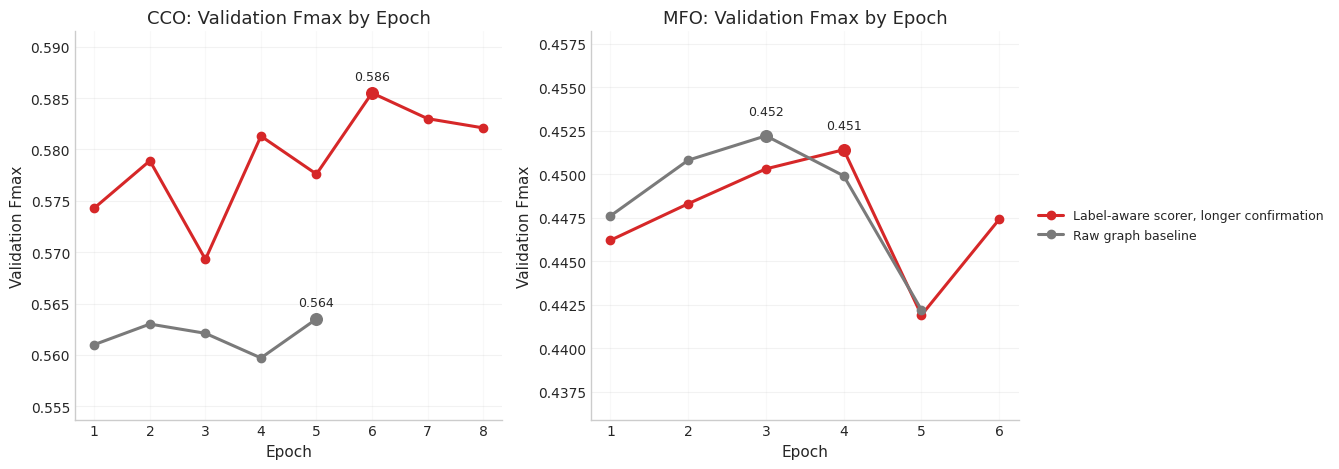

**Compact loss/Fmax trajectory summary**

,aspect,Run label,first_train_loss,final_train_loss,best_val_loss,best_val_fmax
0,CCO,"Label-aware scorer, longer confirmation",2.3126,0.0330,0.0320,0.5855
1,CCO,Raw graph baseline,0.0463,0.0341,0.0334,0.5635
2,MFO,"Label-aware scorer, longer confirmation",2.7878,0.0206,0.0197,0.4514
3,MFO,Raw graph baseline,0.0349,0.0206,0.0199,0.4522


<div style='background:#eef6ff; border-left:4px solid #5b8fd8; padding:0.75rem 1rem;'>Interpretation: the plotted Fmax trajectory is easier to interpret than raw loss because the label-aware head changes the loss scale. Exact train/validation loss summaries are shown in the table.</div>

In [7]:
best_results_path = REPORT_ASSETS / "graph_training_best_results.csv"
epoch_metrics_path = REPORT_ASSETS / "graph_training_epoch_metrics.csv"
best_results = safe_read_csv(best_results_path)
epoch_metrics = safe_read_csv(epoch_metrics_path)

if not best_results.empty:
    cols = ["stage", "model_change", "aspect", "status", "best_epoch", "best_val_fmax", "best_test_fmax", "epochs_completed"]
    display_df(best_results[cols], "Parsed graph training result inventory", max_rows=14)
else:
    note("No parsed graph training result table found.", "warn")

if not epoch_metrics.empty:
    selected_runs = [
        "full_graph_pyg_mtf20_33234089",
        "sigimp_n3_confirm_long_20260425_n3_confirm",
    ]
    plot_df = epoch_metrics[
        epoch_metrics["run_dir"].isin(selected_runs)
        & epoch_metrics["aspect"].isin(["CCO", "MFO"])
    ].copy()
    if not plot_df.empty:
        run_label = {
            "full_graph_pyg_mtf20_33234089": "Raw graph baseline",
            "sigimp_n3_confirm_long_20260425_n3_confirm": "Label-aware scorer, longer confirmation",
        }
        plot_df["Run label"] = plot_df["run_dir"].map(run_label)

        fig, axes = plt.subplots(1, 2, figsize=(13.5, 4.8), sharex=False)
        for ax, aspect in zip(axes, ["CCO", "MFO"]):
            aspect_df = plot_df[plot_df["aspect"] == aspect]
            for label, group in aspect_df.groupby("Run label"):
                group = group.sort_values("epoch")
                ax.plot(
                    group["epoch"],
                    group["val_fmax"],
                    marker="o",
                    lw=2.2,
                    label=label,
                    color=MODEL_COLORS.get(label, None),
                )
                best_row = group.loc[group["val_fmax"].idxmax()]
                ax.scatter(best_row["epoch"], best_row["val_fmax"], s=70, color=MODEL_COLORS.get(label, "black"), zorder=4)
                ax.text(
                    best_row["epoch"],
                    best_row["val_fmax"] + 0.001,
                    f"{best_row['val_fmax']:.3f}",
                    ha="center",
                    va="bottom",
                    fontsize=9,
                )
            ax.set_title(f"{aspect}: Validation Fmax by Epoch")
            ax.set_xlabel("Epoch")
            ax.set_ylabel("Validation Fmax")
            set_zoom_ylim(ax, aspect_df["val_fmax"], margin=0.006, floor=0)
            clean_axis(ax)
        axes[1].legend(loc="center left", bbox_to_anchor=(1.02, 0.5), fontsize=9)
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / "training_validation_loss_curves.png", dpi=180, bbox_inches="tight")
        plt.show()

        loss_summary = (
            plot_df.sort_values(["aspect", "Run label", "epoch"])
            .groupby(["aspect", "Run label"], as_index=False)
            .agg(
                first_train_loss=("train_loss", "first"),
                final_train_loss=("train_loss", "last"),
                best_val_loss=("val_loss", "min"),
                best_val_fmax=("val_fmax", "max"),
            )
        )
        display_df(loss_summary, "Compact loss/Fmax trajectory summary", max_rows=10)
        note("Interpretation: the plotted Fmax trajectory is easier to interpret than raw loss because the label-aware head changes the loss scale. Exact train/validation loss summaries are shown in the table.", "info")
else:
    note("Per-epoch metric table is unavailable, so training trajectories cannot be plotted.", "warn")

## 6. Evaluation Metrics

Accuracy is not appropriate for GO prediction because the label matrix is sparse:
a model can predict all negatives and appear accurate while failing to identify
functions. The repository therefore reports metrics suited to multi-label
classification.

- **Precision:** among predicted GO terms, the fraction that are true.
- **Recall:** among true GO terms, the fraction recovered by the model.
- **Micro-F1:** aggregates true positives, false positives, and false negatives
  over all proteins and terms before computing F1. This emphasizes common
  labels.
- **Macro-F1:** computes label-wise F1 and averages across labels. This is
  sensitive to rare-label performance.
- **Fmax:** sweeps decision thresholds and reports the best F1. This is common
  in CAFA-style protein function evaluation because score calibration differs
  across models.
- **AUPRC:** when prediction bundles are available, a micro precision-recall
  curve and area under the curve are computed from scores directly.


In [8]:
def safe_ratio(num: float, den: float) -> float:
    return 0.0 if den == 0 else float(num / den)

def multilabel_counts(scores: np.ndarray, targets: np.ndarray, threshold: float) -> dict[str, float]:
    pred = scores >= threshold
    truth = targets >= 0.5
    tp = float(np.logical_and(pred, truth).sum())
    fp = float(np.logical_and(pred, ~truth).sum())
    fn = float(np.logical_and(~pred, truth).sum())
    precision = safe_ratio(tp, tp + fp)
    recall = safe_ratio(tp, tp + fn)
    f1 = safe_ratio(2 * precision * recall, precision + recall)
    return {"precision": precision, "recall": recall, "f1": f1, "tp": tp, "fp": fp, "fn": fn}

def fmax(scores: np.ndarray, targets: np.ndarray, step: float = 0.01) -> dict[str, float]:
    best = {"threshold": 0.0, "precision": 0.0, "recall": 0.0, "f1": 0.0}
    thresholds = np.arange(0.0, 1.0 + 1e-9, step)
    for threshold in thresholds:
        metrics = multilabel_counts(scores, targets, float(threshold))
        if metrics["f1"] > best["f1"]:
            best = {"threshold": float(threshold), "precision": metrics["precision"], "recall": metrics["recall"], "f1": metrics["f1"]}
    return best

def micro_pr_curve(scores: np.ndarray, targets: np.ndarray, points: int = 101) -> pd.DataFrame:
    rows = []
    for threshold in np.linspace(1.0, 0.0, points):
        metrics = multilabel_counts(scores, targets, float(threshold))
        rows.append({"threshold": threshold, "precision": metrics["precision"], "recall": metrics["recall"]})
    curve = pd.DataFrame(rows).sort_values("recall")
    return curve

def auprc_from_curve(curve: pd.DataFrame) -> float:
    if curve.empty:
        return float("nan")
    return float(np.trapz(curve["precision"].to_numpy(), curve["recall"].to_numpy()))


## 7. Core Comparison: Sequence vs Structure-Enhanced Model

This section separates two kinds of comparisons:

1. **Historical team baselines from the progress reports.** These show the team's sequence-model progression from k-mer features to ESM embeddings. They are useful context, but they are not fully controlled comparisons against the AlphaFold graph model because the cohort, label space, and metric differ.
2. **Matched structure-cohort comparison.** This is the controlled experiment for the research question: keep the dataset split and MFO label vocabulary fixed, then compare sequence-only ESM2 scores against AlphaFold graph scores.

For CCO, the repository contains strong graph-side results, including the label-aware N3 scorer, but no matched sequence-only CCO prediction bundle was found in the inspected artifacts. BPO full graph training was memory-limited and is not treated as a formal graph comparison result.

### 7.1 Historical Team Progress Baselines

The uploaded progress reports document the team baseline development before the final matched graph experiment:

- `checkpoint1.pdf`: CAFA5 data exploration, valid-sequence cleaning, k-mer features, ESM features, and AlphaFold graph cache walkthrough.
- `checkpoint2.pdf` and `checkpoint3.pdf`: full-GO k-mer and ESM MLP training/tuning.
- `checkpoint4.pdf`: GO-split k-mer and ESM checkpoint error analysis.

These results are worth mentioning because they show why the project moved beyond a simple sequence baseline. They should be presented as **historical baselines**, not as a strict apples-to-apples comparison with the AlphaFold graph model.

**Historical teammate baseline metrics extracted from progress reports**

,Source,Experiment,Feature family,Comparison scope,Aspect,Metric,Value,Threshold,Notes
0,checkpoint3.pdf,All-GO k-mer MLP,k-mer,all GO terms,All GO,micro-F1,0.150363,0.75,"2-mer frequency vector, 400-d input; 31,454-la..."
1,checkpoint3.pdf,All-GO k-mer MLP,k-mer,all GO terms,All GO,macro-F1,0.046416,0.65,Best macro-F1 threshold differs from best micr...
2,checkpoint3.pdf,All-GO ESM MLP,ESM2,all GO terms,All GO,micro-F1,0.201215,0.75,"Mean-pooled ESM2 embedding, 640-d input; 31,45..."
3,checkpoint3.pdf,All-GO ESM MLP,ESM2,all GO terms,All GO,macro-F1,0.062141,0.75,Same full clean sequence cohort as the k-mer a...
4,checkpoint4.pdf,GO-split k-mer checkpoints,k-mer,GO split,BPO,micro-F1,0.100855,0.75,Namespace-specific final k-mer checkpoint.
5,checkpoint4.pdf,GO-split k-mer checkpoints,k-mer,GO split,CCO,micro-F1,0.146347,0.75,Namespace-specific final k-mer checkpoint.
6,checkpoint4.pdf,GO-split k-mer checkpoints,k-mer,GO split,MFO,micro-F1,0.151838,0.85,Namespace-specific final k-mer checkpoint.
7,checkpoint4.pdf,GO-split ESM checkpoints,ESM2,GO split,BPO,micro-F1,0.184377,0.80,Namespace-specific tuned ESM checkpoint.
8,checkpoint4.pdf,GO-split ESM checkpoints,ESM2,GO split,CCO,micro-F1,0.262880,0.65,Namespace-specific tuned ESM checkpoint.
9,checkpoint4.pdf,GO-split ESM checkpoints,ESM2,GO split,MFO,micro-F1,0.285033,0.90,Namespace-specific tuned ESM checkpoint.


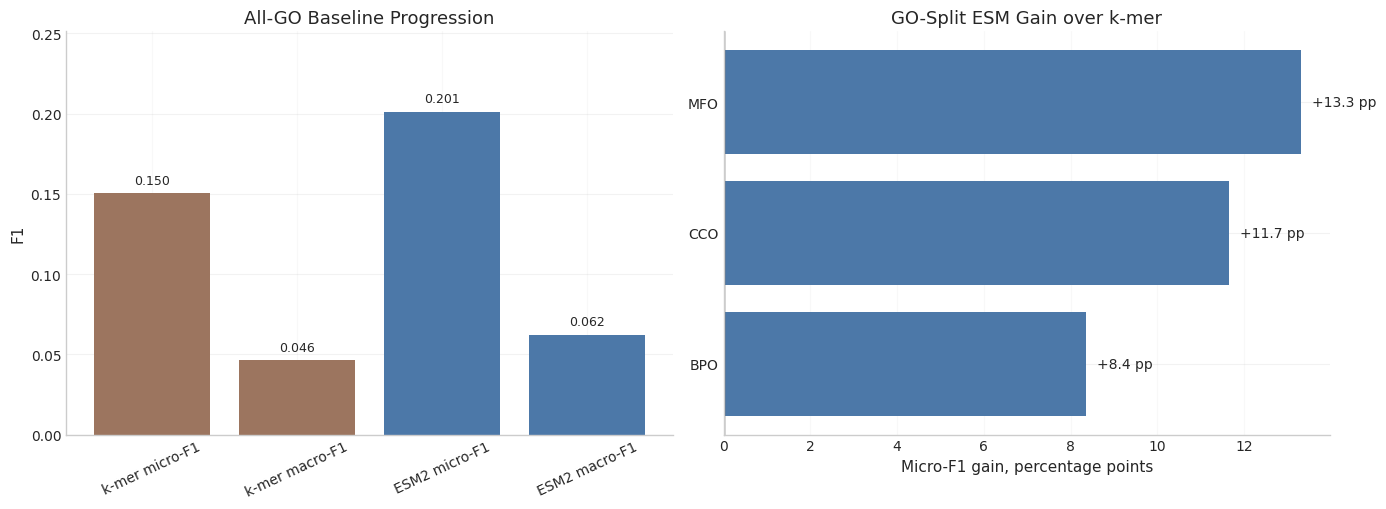

**How to interpret teammate-vs-structure comparisons**

,Comparison,Cohort / labels,Metric,What it tells us
0,Teammate sequence baselines,"Clean sequence cohort; full 31,454-label space...",thresholded micro/macro F1,ESM features strongly improve over 2-mer k-mer...
1,Matched structure experiment below,Structure-available graph cohort; matched MFO ...,validation-selected Fmax plus bundle diagnostics,Whether AlphaFold graph features add signal be...


<div style='background:#eef6ff; border-left:4px solid #5b8fd8; padding:0.75rem 1rem;'>Interpretation: the teammate progress reports establish a clear sequence-model ladder: k-mer < ESM. The final research comparison must still use the matched graph cohort because the AlphaFold model cannot be fairly compared against a different full-label sequence split.</div>

In [9]:
team_baselines = pd.DataFrame([
    {
        "Source": "checkpoint3.pdf",
        "Experiment": "All-GO k-mer MLP",
        "Feature family": "k-mer",
        "Comparison scope": "all GO terms",
        "Aspect": "All GO",
        "Metric": "micro-F1",
        "Value": 0.15036308447686397,
        "Threshold": 0.75,
        "Notes": "2-mer frequency vector, 400-d input; 31,454-label output.",
    },
    {
        "Source": "checkpoint3.pdf",
        "Experiment": "All-GO k-mer MLP",
        "Feature family": "k-mer",
        "Comparison scope": "all GO terms",
        "Aspect": "All GO",
        "Metric": "macro-F1",
        "Value": 0.04641646766062745,
        "Threshold": 0.65,
        "Notes": "Best macro-F1 threshold differs from best micro-F1 threshold.",
    },
    {
        "Source": "checkpoint3.pdf",
        "Experiment": "All-GO ESM MLP",
        "Feature family": "ESM2",
        "Comparison scope": "all GO terms",
        "Aspect": "All GO",
        "Metric": "micro-F1",
        "Value": 0.2012154299395264,
        "Threshold": 0.75,
        "Notes": "Mean-pooled ESM2 embedding, 640-d input; 31,454-label output.",
    },
    {
        "Source": "checkpoint3.pdf",
        "Experiment": "All-GO ESM MLP",
        "Feature family": "ESM2",
        "Comparison scope": "all GO terms",
        "Aspect": "All GO",
        "Metric": "macro-F1",
        "Value": 0.06214149901078674,
        "Threshold": 0.75,
        "Notes": "Same full clean sequence cohort as the k-mer all-GO baseline.",
    },
    {
        "Source": "checkpoint4.pdf",
        "Experiment": "GO-split k-mer checkpoints",
        "Feature family": "k-mer",
        "Comparison scope": "GO split",
        "Aspect": "BPO",
        "Metric": "micro-F1",
        "Value": 0.10085526079523256,
        "Threshold": 0.75,
        "Notes": "Namespace-specific final k-mer checkpoint.",
    },
    {
        "Source": "checkpoint4.pdf",
        "Experiment": "GO-split k-mer checkpoints",
        "Feature family": "k-mer",
        "Comparison scope": "GO split",
        "Aspect": "CCO",
        "Metric": "micro-F1",
        "Value": 0.1463468320868456,
        "Threshold": 0.75,
        "Notes": "Namespace-specific final k-mer checkpoint.",
    },
    {
        "Source": "checkpoint4.pdf",
        "Experiment": "GO-split k-mer checkpoints",
        "Feature family": "k-mer",
        "Comparison scope": "GO split",
        "Aspect": "MFO",
        "Metric": "micro-F1",
        "Value": 0.15183777531219755,
        "Threshold": 0.85,
        "Notes": "Namespace-specific final k-mer checkpoint.",
    },
    {
        "Source": "checkpoint4.pdf",
        "Experiment": "GO-split ESM checkpoints",
        "Feature family": "ESM2",
        "Comparison scope": "GO split",
        "Aspect": "BPO",
        "Metric": "micro-F1",
        "Value": 0.1843773452426078,
        "Threshold": 0.80,
        "Notes": "Namespace-specific tuned ESM checkpoint.",
    },
    {
        "Source": "checkpoint4.pdf",
        "Experiment": "GO-split ESM checkpoints",
        "Feature family": "ESM2",
        "Comparison scope": "GO split",
        "Aspect": "CCO",
        "Metric": "micro-F1",
        "Value": 0.2628795657284716,
        "Threshold": 0.65,
        "Notes": "Namespace-specific tuned ESM checkpoint.",
    },
    {
        "Source": "checkpoint4.pdf",
        "Experiment": "GO-split ESM checkpoints",
        "Feature family": "ESM2",
        "Comparison scope": "GO split",
        "Aspect": "MFO",
        "Metric": "micro-F1",
        "Value": 0.2850332752862512,
        "Threshold": 0.90,
        "Notes": "Namespace-specific tuned ESM checkpoint.",
    },
])

display_df(team_baselines, "Historical teammate baseline metrics extracted from progress reports", max_rows=12)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))

all_go = team_baselines[(team_baselines["Comparison scope"] == "all GO terms")].copy()
all_go["Label"] = all_go["Feature family"] + " " + all_go["Metric"]
colors = [MODEL_COLORS.get(fam, "#777777") for fam in all_go["Feature family"]]
axes[0].bar(all_go["Label"], all_go["Value"], color=colors)
axes[0].set_title("All-GO Baseline Progression")
axes[0].set_ylabel("F1")
axes[0].set_ylim(0, max(all_go["Value"]) + 0.05)
axes[0].tick_params(axis="x", rotation=25)
label_bars(axes[0], fmt="{:.3f}", orient="v", pad=0.004)
clean_axis(axes[0])

split_micro = team_baselines[
    (team_baselines["Comparison scope"] == "GO split") & (team_baselines["Metric"] == "micro-F1")
].copy()
pivot = split_micro.pivot(index="Aspect", columns="Feature family", values="Value").loc[["BPO", "CCO", "MFO"]]
delta = (pivot["ESM2"] - pivot["k-mer"]).rename("ESM2 - k-mer")
y = np.arange(len(delta))
axes[1].barh(y, delta * 100, color="#4C78A8")
axes[1].axvline(0, color="#333333", lw=1)
axes[1].set_yticks(y)
axes[1].set_yticklabels(delta.index)
axes[1].set_xlabel("Micro-F1 gain, percentage points")
axes[1].set_title("GO-Split ESM Gain over k-mer")
for yi, val in zip(y, delta * 100):
    axes[1].text(val + 0.25, yi, f"+{val:.1f} pp", va="center", fontsize=10)
clean_axis(axes[1])

plt.tight_layout()
plt.savefig(FIGURE_DIR / "team_progress_sequence_baselines.png", dpi=180, bbox_inches="tight")
plt.show()

context_rows = pd.DataFrame([
    {
        "Comparison": "Teammate sequence baselines",
        "Cohort / labels": "Clean sequence cohort; full 31,454-label space or GO-split full label space",
        "Metric": "thresholded micro/macro F1",
        "What it tells us": "ESM features strongly improve over 2-mer k-mer counts, but rare-label performance remains difficult.",
    },
    {
        "Comparison": "Matched structure experiment below",
        "Cohort / labels": "Structure-available graph cohort; matched MFO split and graph vocabulary",
        "Metric": "validation-selected Fmax plus bundle diagnostics",
        "What it tells us": "Whether AlphaFold graph features add signal beyond the matched sequence-only ESM2 branch.",
    },
])
display_df(context_rows, "How to interpret teammate-vs-structure comparisons", max_rows=5)

note("Interpretation: the teammate progress reports establish a clear sequence-model ladder: k-mer < ESM. The final research comparison must still use the matched graph cohort because the AlphaFold model cannot be fairly compared against a different full-label sequence split.", "info")

### 7.2 Controlled Matched-Cohort Structure Experiment

The cleanest available sequence-vs-structure comparison in the artifacts is the MFO matched-cohort N4 experiment:

- **Sequence-only baseline:** MLP trained on protein-level ESM2 features exported from graph-cache-aligned sequence artifacts.
- **Structure-enhanced model:** graph model trained on AlphaFold-derived residue contact graphs, with the same MFO split and label vocabulary.
- **Late fusion diagnostic:** score-level weighted average between sequence and graph branches.

The plots below intentionally emphasize both **absolute performance** and **delta from the sequence baseline**. This makes small but scientifically relevant differences visible without hiding the true scale.

**Matched MFO sequence-vs-structure comparison**

,Model,Aspect,Val Fmax,Test Fmax,Micro-F1,Macro-F1,Entry count,Term count,Delta Test Fmax vs sequence (pp),Delta Val Fmax vs sequence (pp)
0,Sequence-only ESM2 MLP,MFO,0.451252,0.455682,0.430348,0.002024,7302,1521,0.000000,0.000000
1,Structure-enhanced graph,MFO,0.451704,0.457978,0.425338,0.002096,7302,1521,0.229630,0.045215
2,Val-selected fusion (g0p8_s0p2),MFO,0.452881,0.457901,0.427700,0.002097,7302,1521,0.221946,0.162828


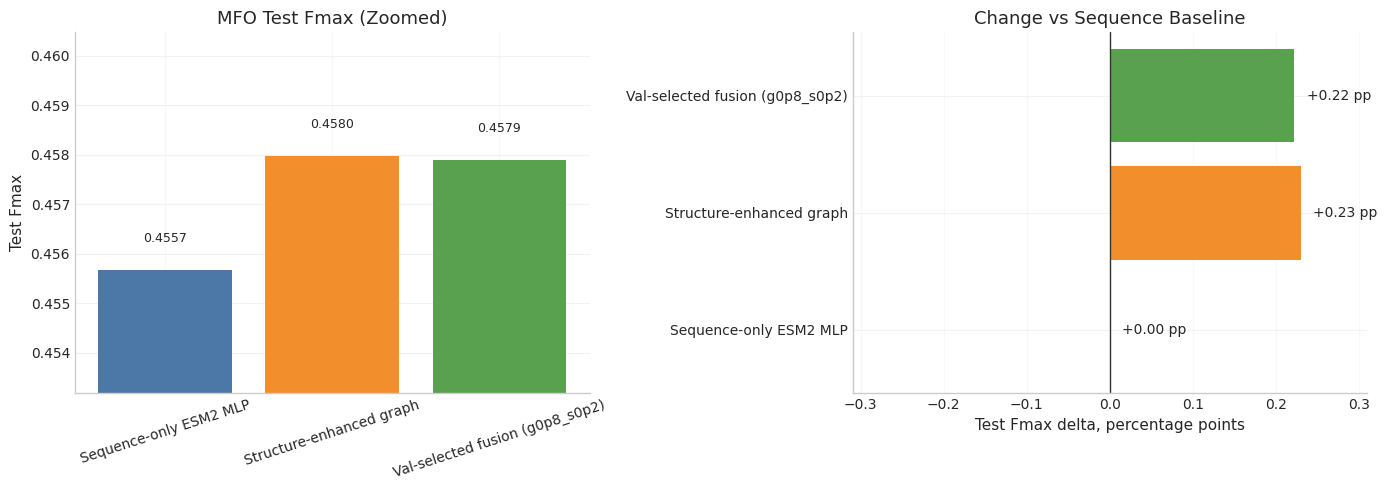

<div style='background:#eef6ff; border-left:4px solid #5b8fd8; padding:0.75rem 1rem;'>Interpretation: on the matched MFO split, graph-only and sequence-only performance are nearly tied. The delta panel shows that any test-set gain is small; this supports a cautious conclusion of weak complementarity rather than a decisive structure win for MFO.</div>

In [10]:
fusion_summary_path = FUSION_ROOT / "n4_mfo_x_seq_graph_vocab_20260424_222500" / "summary.tsv"
if not fusion_summary_path.exists():
    fusion_summary_path = FUSION_ROOT / "n3_mfo_x_seq_graph_vocab_20260424_222500" / "summary.tsv"
if not fusion_summary_path.exists():
    fusion_summary_path = FUSION_ROOT / "raw_mfo_x_seq_graph_vocab_20260424_222500" / "summary.tsv"

fusion_summary = pd.read_csv(fusion_summary_path, sep="\t") if fusion_summary_path.exists() else pd.DataFrame()

comparison_rows = []
if not fusion_summary.empty:
    test_rows = fusion_summary[fusion_summary["split"] == "test"].copy()
    val_rows = fusion_summary[fusion_summary["split"] == "val"].copy()
    def row_for_weight(weight_label: str, model_name: str):
        t = test_rows[test_rows["weight_label"] == weight_label]
        v = val_rows[val_rows["weight_label"] == weight_label]
        if not t.empty:
            comparison_rows.append({
                "Model": model_name,
                "Aspect": "MFO",
                "Val Fmax": float(v["fmax"].iloc[0]) if not v.empty else np.nan,
                "Test Fmax": float(t["fmax"].iloc[0]),
                "Micro-F1": float(t["micro_f1"].iloc[0]),
                "Macro-F1": float(t["macro_f1"].iloc[0]),
                "Entry count": int(t["entry_count"].iloc[0]),
                "Term count": int(t["term_count"].iloc[0]),
            })
    row_for_weight("g0p0_s1p0", "Sequence-only ESM2 MLP")
    row_for_weight("g1p0_s0p0", "Structure-enhanced graph")
    if not val_rows.empty:
        best_val_weight = val_rows.sort_values("fmax", ascending=False).iloc[0]["weight_label"]
        row_for_weight(best_val_weight, f"Val-selected fusion ({best_val_weight})")

comparison_df = pd.DataFrame(comparison_rows)
if not comparison_df.empty:
    seq_test_fmax = comparison_df.loc[comparison_df["Model"] == "Sequence-only ESM2 MLP", "Test Fmax"]
    baseline_value = float(seq_test_fmax.iloc[0]) if not seq_test_fmax.empty else float(comparison_df["Test Fmax"].iloc[0])
    comparison_df["Delta Test Fmax vs sequence (pp)"] = (comparison_df["Test Fmax"] - baseline_value) * 100
    comparison_df["Delta Val Fmax vs sequence (pp)"] = (comparison_df["Val Fmax"] - float(comparison_df.loc[comparison_df["Model"] == "Sequence-only ESM2 MLP", "Val Fmax"].iloc[0])) * 100

display_df(comparison_df, "Matched MFO sequence-vs-structure comparison", max_rows=10)

if not comparison_df.empty:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.0))
    colors = [MODEL_COLORS.get(m.split(" (")[0], MODEL_COLORS.get(m, "#777777")) for m in comparison_df["Model"]]

    axes[0].bar(comparison_df["Model"], comparison_df["Test Fmax"], color=colors)
    axes[0].set_title("MFO Test Fmax (Zoomed)")
    axes[0].set_ylabel("Test Fmax")
    axes[0].tick_params(axis="x", rotation=18)
    set_zoom_ylim(axes[0], comparison_df["Test Fmax"], margin=0.0025, floor=0)
    label_bars(axes[0], fmt="{:.4f}", orient="v", pad=0.0005)
    clean_axis(axes[0])

    delta_df = comparison_df.copy()
    axes[1].barh(delta_df["Model"], delta_df["Delta Test Fmax vs sequence (pp)"], color=colors)
    axes[1].axvline(0, color="#333333", lw=1)
    axes[1].set_title("Change vs Sequence Baseline")
    axes[1].set_xlabel("Test Fmax delta, percentage points")
    for y_pos, value in enumerate(delta_df["Delta Test Fmax vs sequence (pp)"]):
        ha = "left" if value >= 0 else "right"
        offset = 0.015 if value >= 0 else -0.015
        axes[1].text(value + offset, y_pos, f"{value:+.2f} pp", va="center", ha=ha, fontsize=10)
    max_abs = max(0.08, float(delta_df["Delta Test Fmax vs sequence (pp)"].abs().max()) + 0.08)
    axes[1].set_xlim(-max_abs, max_abs)
    clean_axis(axes[1])

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "overall_mfo_sequence_structure_comparison.png", dpi=180, bbox_inches="tight")
    plt.show()
    note("Interpretation: on the matched MFO split, graph-only and sequence-only performance are nearly tied. The delta panel shows that any test-set gain is small; this supports a cautious conclusion of weak complementarity rather than a decisive structure win for MFO.", "info")
else:
    note("Fusion summary is missing. Expected `n4_fusion/*/summary.tsv` to plot the matched sequence-vs-structure comparison.", "warn")

**Per-ontology graph-side comparison with deltas**

,stage,model_change,aspect,best_epoch,best_val_fmax,best_test_fmax,Delta vs raw baseline (pp)
24,Follow-up model changes,"Label-aware scorer, longer confirmation",CCO,6,0.5855,0.5875,2.28
16,Targeted local tuning,Weighted BCE,CCO,1,0.5640,0.5656,0.09
0,Initial comparison,Raw graph baseline,CCO,5,0.5635,0.5647,0.00
17,Targeted local tuning,Weighted BCE,MFO,3,0.4551,0.4605,0.31
25,Follow-up model changes,"Label-aware scorer, longer confirmation",MFO,4,0.4514,0.4575,0.01
1,Initial comparison,Raw graph baseline,MFO,3,0.4522,0.4574,0.00


/tmp/ipykernel_3992976/750499863.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


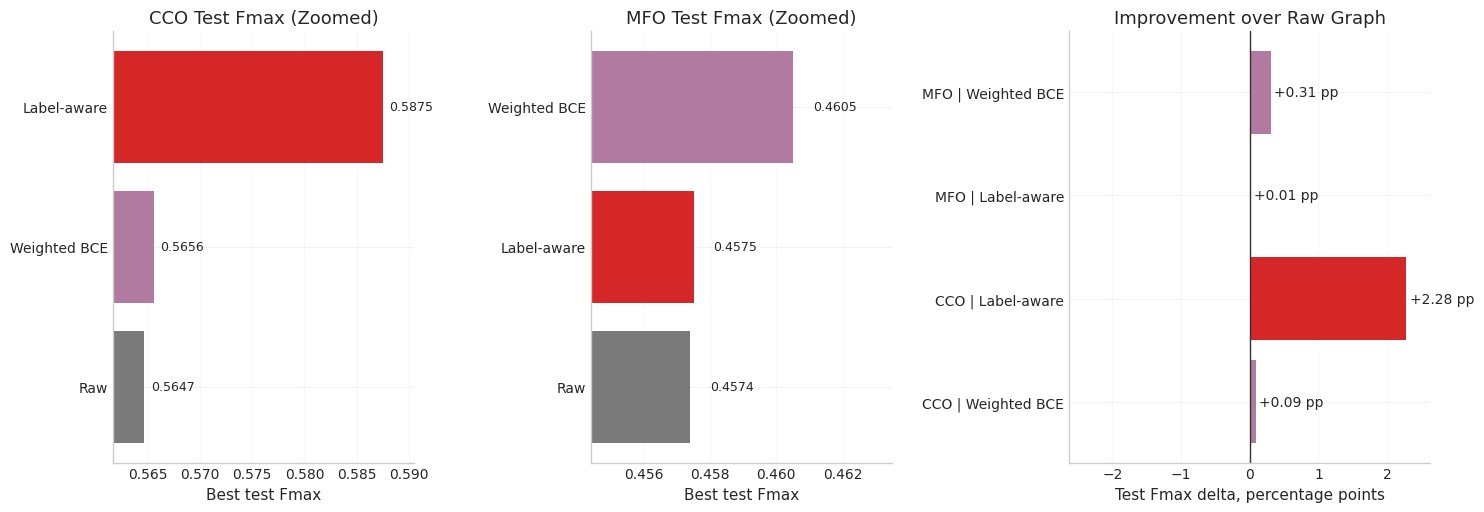

<div style='background:#eef6ff; border-left:4px solid #5b8fd8; padding:0.75rem 1rem;'>Interpretation: the graph-side breakthrough is concentrated in CCO, where the label-aware scorer improves test Fmax by multiple percentage points. MFO remains close to the raw graph baseline, so MFO needs either better modality fusion or a different modeling change.</div>

In [11]:
if not best_results.empty:
    selected_models = [
        "Raw graph baseline",
        "Weighted BCE",
        "Label-aware scorer, longer confirmation",
    ]
    graph_plot = best_results[
        best_results["model_change"].isin(selected_models)
        & best_results["aspect"].isin(["CCO", "MFO"])
    ].copy()
    if not graph_plot.empty:
        raw_by_aspect = (
            graph_plot[graph_plot["model_change"] == "Raw graph baseline"]
            .set_index("aspect")["best_test_fmax"]
            .to_dict()
        )
        graph_plot["Delta vs raw baseline (pp)"] = graph_plot.apply(
            lambda row: (row["best_test_fmax"] - raw_by_aspect.get(row["aspect"], np.nan)) * 100,
            axis=1,
        )
        short_names = {
            "Raw graph baseline": "Raw",
            "Weighted BCE": "Weighted BCE",
            "Label-aware scorer, longer confirmation": "Label-aware",
        }
        graph_plot["Short model"] = graph_plot["model_change"].map(short_names).fillna(graph_plot["model_change"])
        graph_plot["Display"] = graph_plot["aspect"] + " | " + graph_plot["Short model"]
        display_df(
            graph_plot[["stage", "model_change", "aspect", "best_epoch", "best_val_fmax", "best_test_fmax", "Delta vs raw baseline (pp)"]]
            .sort_values(["aspect", "best_test_fmax"], ascending=[True, False]),
            "Per-ontology graph-side comparison with deltas",
            max_rows=20,
        )

        fig = plt.figure(figsize=(17, 5.6))
        grid = fig.add_gridspec(1, 3, width_ratios=[1.0, 1.0, 1.2], wspace=0.55)
        aspect_axes = [fig.add_subplot(grid[0, 0]), fig.add_subplot(grid[0, 1])]
        delta_ax = fig.add_subplot(grid[0, 2])

        for ax, aspect in zip(aspect_axes, ["CCO", "MFO"]):
            aspect_df = graph_plot[graph_plot["aspect"] == aspect].sort_values("best_test_fmax")
            colors = [MODEL_COLORS.get(m, "#777777") for m in aspect_df["model_change"]]
            ax.barh(aspect_df["Short model"], aspect_df["best_test_fmax"], color=colors)
            ax.set_title(f"{aspect} Test Fmax (Zoomed)")
            ax.set_xlabel("Best test Fmax")
            set_zoom_xlim(ax, aspect_df["best_test_fmax"], margin=0.003, floor=0)
            label_bars(ax, fmt="{:.4f}", orient="h", pad=0.0006)
            clean_axis(ax)

        delta_order = graph_plot[graph_plot["model_change"] != "Raw graph baseline"].copy()
        delta_order = delta_order.sort_values(["aspect", "Delta vs raw baseline (pp)"])
        delta_ax.barh(delta_order["Display"], delta_order["Delta vs raw baseline (pp)"], color=[MODEL_COLORS.get(m, "#777777") for m in delta_order["model_change"]])
        delta_ax.axvline(0, color="#333333", lw=1)
        delta_ax.set_title("Improvement over Raw Graph")
        delta_ax.set_xlabel("Test Fmax delta, percentage points")
        for y_pos, value in enumerate(delta_order["Delta vs raw baseline (pp)"]):
            ha = "left" if value >= 0 else "right"
            offset = 0.05 if value >= 0 else -0.05
            delta_ax.text(value + offset, y_pos, f"{value:+.2f} pp", va="center", ha=ha, fontsize=10)
        max_abs = max(0.4, float(delta_order["Delta vs raw baseline (pp)"].abs().max()) + 0.35)
        delta_ax.set_xlim(-max_abs, max_abs)
        clean_axis(delta_ax)

        plt.tight_layout()
        plt.savefig(FIGURE_DIR / "per_ontology_graph_comparison.png", dpi=180, bbox_inches="tight")
        plt.show()
        note("Interpretation: the graph-side breakthrough is concentrated in CCO, where the label-aware scorer improves test Fmax by multiple percentage points. MFO remains close to the raw graph baseline, so MFO needs either better modality fusion or a different modeling change.", "info")
else:
    note("Graph best-results table is missing, so per-ontology comparison cannot be plotted.", "warn")

### Prediction-Bundle Analyses

The remaining comparison plots require prediction bundles (`scores.npy`,
`entry_ids.txt`, `terms.txt`) for both the sequence and graph branches. If these
bundles are available, the notebook computes:

1. performance vs GO term frequency,
2. precision-recall curves,
3. example protein-level predictions.


In [12]:
sequence_bundle_root = SEQUENCE_RUN_ROOT / "sigimp_n4_seq_graph_vocab_mfo_mlp_20260424_222500" / "prediction_bundles"
graph_bundle_root = FUSION_ROOT / "n3_mfo_x_seq_graph_vocab_20260424_222500" / "graph_bundles" / "sigimp_n3_label_dot_20260422_172916_mfo"
raw_graph_bundle_root = FUSION_ROOT / "raw_mfo_x_seq_graph_vocab_20260424_222500" / "graph_bundles" / "raw_mfo_full_graph_pyg_mtf20_33234089"

def load_bundle(bundle_root: Path, split: str) -> dict[str, Any] | None:
    bundle_dir = bundle_root / split
    required = [bundle_dir / "scores.npy", bundle_dir / "entry_ids.txt", bundle_dir / "terms.txt"]
    if not all(path.exists() for path in required):
        return None
    return {
        "dir": bundle_dir,
        "scores": np.load(bundle_dir / "scores.npy"),
        "entry_ids": read_lines(bundle_dir / "entry_ids.txt"),
        "terms": read_lines(bundle_dir / "terms.txt"),
        "meta": read_json(bundle_dir / "meta.json") or {},
    }

def build_targets(entry_ids: list[str], terms: list[str], aspect: str = "MFO") -> np.ndarray | None:
    entries = read_json(entries_path)
    if entries is None:
        return None
    labels_by_entry = {str(entry["entry_id"]): set((entry.get("labels") or {}).get(aspect, [])) for entry in entries}
    targets = np.zeros((len(entry_ids), len(terms)), dtype=np.float32)
    term_index = {term: idx for idx, term in enumerate(terms)}
    for row, entry_id in enumerate(entry_ids):
        for term in labels_by_entry.get(entry_id, set()):
            col = term_index.get(term)
            if col is not None:
                targets[row, col] = 1.0
    return targets

def align_bundle_to_reference(bundle: dict[str, Any], ref_entry_ids: list[str], ref_terms: list[str]) -> tuple[dict[str, Any] | None, str | None]:
    """Reindex a score bundle to a reference row/column order when sets match."""
    if set(bundle["entry_ids"]) != set(ref_entry_ids):
        return None, "entry ID set mismatch"
    if set(bundle["terms"]) != set(ref_terms):
        return None, "GO term set mismatch"
    row_index = {entry_id: idx for idx, entry_id in enumerate(bundle["entry_ids"])}
    col_index = {term: idx for idx, term in enumerate(bundle["terms"])}
    row_order = [row_index[entry_id] for entry_id in ref_entry_ids]
    col_order = [col_index[term] for term in ref_terms]
    aligned = dict(bundle)
    aligned["scores"] = bundle["scores"][np.ix_(row_order, col_order)]
    aligned["entry_ids"] = list(ref_entry_ids)
    aligned["terms"] = list(ref_terms)
    return aligned, None

seq_val = load_bundle(sequence_bundle_root, "val")
seq_test = load_bundle(sequence_bundle_root, "test")
graph_val = load_bundle(graph_bundle_root, "val")
graph_test = load_bundle(graph_bundle_root, "test")

bundles_ready = all(bundle is not None for bundle in [seq_val, seq_test, graph_val, graph_test])
if bundles_ready:
    bundle_alignment = [
        ("validation", seq_val, graph_val),
        ("test", seq_test, graph_test),
    ]
    for split_name, seq_bundle, graph_bundle in bundle_alignment:
        aligned_graph_bundle, reason = align_bundle_to_reference(graph_bundle, seq_bundle["entry_ids"], seq_bundle["terms"])
        if aligned_graph_bundle is None:
            note(f"Sequence and graph {split_name} bundles cannot be aligned ({reason}); skipping bundle-level comparison plots.", "warn")
            bundles_ready = False
            break
        if split_name == "validation":
            graph_val = aligned_graph_bundle
        else:
            graph_test = aligned_graph_bundle

if bundles_ready:
    y_val = build_targets(seq_val["entry_ids"], seq_val["terms"], "MFO")
    y_test = build_targets(seq_test["entry_ids"], seq_test["terms"], "MFO")
    bundles_ready = y_val is not None and y_test is not None

if not bundles_ready:
    note(
        "Prediction bundles or graph metadata are missing. Expected sequence bundles under "
        f"`{sequence_bundle_root}` and graph bundles under `{graph_bundle_root}`. "
        "Frequency-stratified plots, PR curves, and example predictions require these files.",
        "warn",
    )
else:
    seq_fmax_val = fmax(seq_val["scores"], y_val)
    graph_fmax_val = fmax(graph_val["scores"], y_val)
    bundle_metrics = pd.DataFrame([
        {"Model": "Sequence-only ESM2 MLP", "Val-selected threshold": seq_fmax_val["threshold"], "Val Fmax recomputed": seq_fmax_val["f1"]},
        {"Model": "Structure-enhanced graph", "Val-selected threshold": graph_fmax_val["threshold"], "Val Fmax recomputed": graph_fmax_val["f1"]},
    ])
    display_df(bundle_metrics, "Prediction-bundle validation thresholds")


**Prediction-bundle validation thresholds**

,Model,Val-selected threshold,Val Fmax recomputed
0,Sequence-only ESM2 MLP,0.29,0.451252
1,Structure-enhanced graph,0.21,0.451704


**Performance vs GO term frequency**

,frequency_bin,GO terms in bin,Mean sequence F1,Mean graph F1,Median test positives,Graph - sequence F1 (pp)
0,<=20,45,0.000000,0.000000,3.0,0.00000
1,21-50,609,0.000000,0.000000,3.0,0.00000
2,51-100,311,0.000000,0.000000,7.0,0.00000
3,101-250,240,0.000000,0.000000,14.0,0.00000
4,251-500,110,0.000000,0.000000,33.5,0.00000
5,501-1000,66,0.000000,0.000000,77.0,0.00000
6,>1000,91,0.045834,0.054848,206.0,0.90139


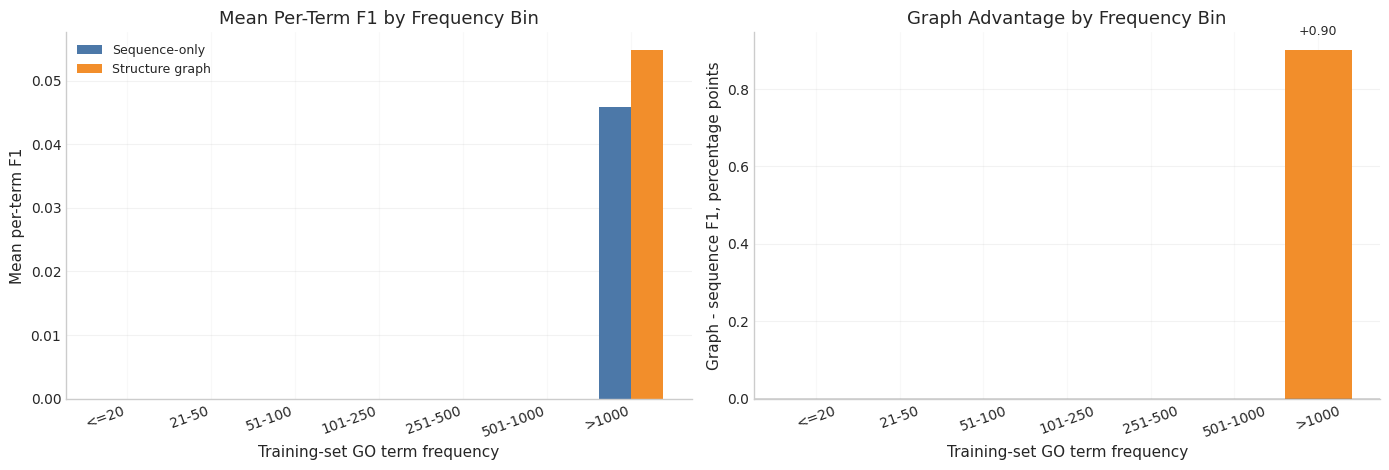

<div style='background:#eef6ff; border-left:4px solid #5b8fd8; padding:0.75rem 1rem;'>Interpretation: the right panel is the key diagnostic. It shows whether graph features help or hurt within each frequency bin, which is clearer than comparing two nearly overlapping bar series alone.</div>

In [13]:
if bundles_ready:
    terms = seq_test["terms"]
    term_counts = (read_json(term_counts_path) or {}).get("MFO", {})
    frequencies = np.array([int(term_counts.get(term, int(y_test[:, i].sum()))) for i, term in enumerate(terms)])

    def per_label_f1(scores: np.ndarray, targets: np.ndarray, threshold: float) -> np.ndarray:
        pred = scores >= threshold
        truth = targets >= 0.5
        tp = np.logical_and(pred, truth).sum(axis=0).astype(float)
        fp = np.logical_and(pred, ~truth).sum(axis=0).astype(float)
        fn = np.logical_and(~pred, truth).sum(axis=0).astype(float)
        denom = 2 * tp + fp + fn
        out = np.zeros_like(tp, dtype=float)
        mask = denom > 0
        out[mask] = (2 * tp[mask]) / denom[mask]
        return out

    seq_label_f1 = per_label_f1(seq_test["scores"], y_test, seq_fmax_val["threshold"])
    graph_label_f1 = per_label_f1(graph_test["scores"], y_test, graph_fmax_val["threshold"])
    perf_freq = pd.DataFrame({
        "term": terms,
        "frequency": frequencies,
        "sequence_f1": seq_label_f1,
        "graph_f1": graph_label_f1,
        "test_positives": y_test.sum(axis=0),
    })
    perf_freq = perf_freq[perf_freq["test_positives"] > 0].copy()
    bins = [0, 20, 50, 100, 250, 500, 1000, np.inf]
    labels = ["<=20", "21-50", "51-100", "101-250", "251-500", "501-1000", ">1000"]
    perf_freq["frequency_bin"] = pd.cut(perf_freq["frequency"], bins=bins, labels=labels, include_lowest=True)
    binned = (
        perf_freq.groupby("frequency_bin", observed=False)
        .agg(
            terms=("term", "count"),
            mean_sequence_f1=("sequence_f1", "mean"),
            mean_graph_f1=("graph_f1", "mean"),
            median_test_positives=("test_positives", "median"),
        )
        .reset_index()
    )
    binned["Graph - sequence F1 (pp)"] = (binned["mean_graph_f1"] - binned["mean_sequence_f1"]) * 100
    display_df(
        binned.rename(columns={
            "mean_sequence_f1": "Mean sequence F1",
            "mean_graph_f1": "Mean graph F1",
            "terms": "GO terms in bin",
            "median_test_positives": "Median test positives",
        }),
        "Performance vs GO term frequency",
        max_rows=10,
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 4.8))
    x = np.arange(len(binned))
    width = 0.38
    axes[0].bar(x - width / 2, binned["mean_sequence_f1"], width=width, label="Sequence-only", color=MODEL_COLORS["Sequence-only ESM2 MLP"])
    axes[0].bar(x + width / 2, binned["mean_graph_f1"], width=width, label="Structure graph", color=MODEL_COLORS["Structure-enhanced graph"])
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(binned["frequency_bin"].astype(str), rotation=20, ha="right")
    axes[0].set_title("Mean Per-Term F1 by Frequency Bin")
    axes[0].set_xlabel("Training-set GO term frequency")
    axes[0].set_ylabel("Mean per-term F1")
    axes[0].legend(fontsize=9)
    clean_axis(axes[0])

    delta_colors = np.where(binned["Graph - sequence F1 (pp)"] >= 0, MODEL_COLORS["Structure-enhanced graph"], MODEL_COLORS["Sequence-only ESM2 MLP"])
    axes[1].bar(binned["frequency_bin"].astype(str), binned["Graph - sequence F1 (pp)"], color=delta_colors)
    axes[1].axhline(0, color="#333333", lw=1)
    axes[1].set_title("Graph Advantage by Frequency Bin")
    axes[1].set_xlabel("Training-set GO term frequency")
    axes[1].set_ylabel("Graph - sequence F1, percentage points")
    axes[1].tick_params(axis="x", rotation=20)
    for xi, val in enumerate(binned["Graph - sequence F1 (pp)"]):
        if abs(val) < 0.01:
            continue
        va = "bottom" if val >= 0 else "top"
        offset = 0.03 if val >= 0 else -0.03
        axes[1].text(xi, val + offset, f"{val:+.2f}", ha="center", va=va, fontsize=9)
    clean_axis(axes[1])

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "performance_vs_go_term_frequency.png", dpi=180, bbox_inches="tight")
    plt.show()

    note("Interpretation: the right panel is the key diagnostic. It shows whether graph features help or hurt within each frequency bin, which is clearer than comparing two nearly overlapping bar series alone.", "info")

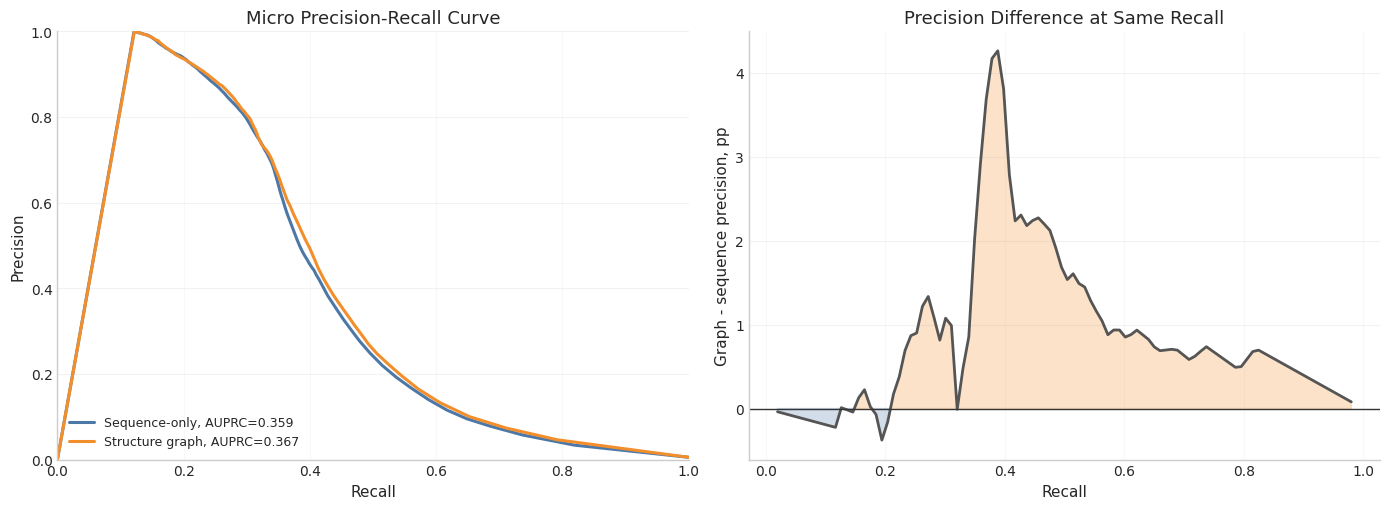

**Approximate AUPRC from bundle score sweeps**

,Model,Approx micro AUPRC
0,Sequence-only ESM2 MLP,0.359027
1,Structure-enhanced graph,0.367455
2,Graph - sequence,0.008428


<div style='background:#eef6ff; border-left:4px solid #5b8fd8; padding:0.75rem 1rem;'>Interpretation: when PR curves overlap, the precision-difference panel makes the direction and size of the difference easier to read. Small AUPRC deltas should be interpreted cautiously.</div>

In [14]:
if bundles_ready:
    seq_curve = micro_pr_curve(seq_test["scores"], y_test, points=151)
    graph_curve = micro_pr_curve(graph_test["scores"], y_test, points=151)
    seq_auc = auprc_from_curve(seq_curve)
    graph_auc = auprc_from_curve(graph_curve)

    common_recall = np.linspace(0.02, 0.98, 100)
    seq_interp = np.interp(common_recall, seq_curve["recall"].sort_values(), seq_curve.sort_values("recall")["precision"])
    graph_interp = np.interp(common_recall, graph_curve["recall"].sort_values(), graph_curve.sort_values("recall")["precision"])

    fig, axes = plt.subplots(1, 2, figsize=(14, 5.2))
    axes[0].plot(seq_curve["recall"], seq_curve["precision"], label=f"Sequence-only, AUPRC={seq_auc:.3f}", color=MODEL_COLORS["Sequence-only ESM2 MLP"], lw=2.2)
    axes[0].plot(graph_curve["recall"], graph_curve["precision"], label=f"Structure graph, AUPRC={graph_auc:.3f}", color=MODEL_COLORS["Structure-enhanced graph"], lw=2.2)
    axes[0].set_title("Micro Precision-Recall Curve")
    axes[0].set_xlabel("Recall")
    axes[0].set_ylabel("Precision")
    axes[0].set_xlim(0, 1)
    axes[0].set_ylim(0, 1)
    axes[0].legend(loc="lower left", fontsize=9)
    clean_axis(axes[0])

    precision_delta = (graph_interp - seq_interp) * 100
    axes[1].plot(common_recall, precision_delta, color="#555555", lw=2)
    axes[1].axhline(0, color="#333333", lw=1)
    axes[1].fill_between(common_recall, 0, precision_delta, where=precision_delta >= 0, color=MODEL_COLORS["Structure-enhanced graph"], alpha=0.25, interpolate=True)
    axes[1].fill_between(common_recall, 0, precision_delta, where=precision_delta < 0, color=MODEL_COLORS["Sequence-only ESM2 MLP"], alpha=0.25, interpolate=True)
    axes[1].set_title("Precision Difference at Same Recall")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Graph - sequence precision, pp")
    clean_axis(axes[1])

    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "mfo_precision_recall_curve.png", dpi=180, bbox_inches="tight")
    plt.show()

    auprc_df = pd.DataFrame([
        {"Model": "Sequence-only ESM2 MLP", "Approx micro AUPRC": seq_auc},
        {"Model": "Structure-enhanced graph", "Approx micro AUPRC": graph_auc},
        {"Model": "Graph - sequence", "Approx micro AUPRC": graph_auc - seq_auc},
    ])
    display_df(auprc_df, "Approximate AUPRC from bundle score sweeps")
    note("Interpretation: when PR curves overlap, the precision-difference panel makes the direction and size of the difference easier to read. Small AUPRC deltas should be interpreted cautiously.", "info")

In [15]:
if bundles_ready:
    top_k = 10
    entries = read_json(entries_path) or []
    labels_by_entry = {str(entry["entry_id"]): set((entry.get("labels") or {}).get("MFO", [])) for entry in entries}
    examples = []
    term_array = np.array(seq_test["terms"], dtype=object)
    for i, entry_id in enumerate(seq_test["entry_ids"]):
        true_terms = labels_by_entry.get(entry_id, set())
        if not true_terms:
            continue
        seq_top_idx = np.argsort(seq_test["scores"][i])[-top_k:][::-1]
        graph_top_idx = np.argsort(graph_test["scores"][i])[-top_k:][::-1]
        seq_hits = [term for term in term_array[seq_top_idx] if term in true_terms]
        graph_hits = [term for term in term_array[graph_top_idx] if term in true_terms]
        gain = len(graph_hits) - len(seq_hits)
        if gain <= 0:
            continue
        examples.append({
            "Entry ID": entry_id,
            "True MFO terms": ", ".join(sorted(list(true_terms))[:8]),
            "Sequence top true hits": ", ".join(seq_hits[:5]) if seq_hits else "(none in top 10)",
            "Graph top true hits": ", ".join(graph_hits[:5]) if graph_hits else "(none in top 10)",
            "Hit gain in top 10": gain,
            "Max sequence score": float(seq_test["scores"][i, seq_top_idx[0]]),
            "Max graph score": float(graph_test["scores"][i, graph_top_idx[0]]),
        })
    examples_df = pd.DataFrame(examples).sort_values("Hit gain in top 10", ascending=False).head(8)
    display_df(examples_df, "Example predictions where graph top-10 recovers more true terms", max_rows=8)
    if examples_df.empty:
        note("No graph-improved examples were found under this simple top-10 hit criterion.", "info")
    else:
        note("Interpretation: these are qualitative diagnostics, not independent test cases. They illustrate where structural scores recover additional true GO IDs among the highest-confidence predictions.", "info")


**Example predictions where graph top-10 recovers more true terms**

,Entry ID,True MFO terms,Sequence top true hits,Graph top true hits,Hit gain in top 10,Max sequence score,Max graph score
417,Q9X113,"GO:0003674, GO:0005488, GO:0005515, GO:0030145...","GO:0003674, GO:0005488, GO:0005515","GO:0003674, GO:0005488, GO:0005515, GO:0042802...",4,0.998909,0.999893
90,P21816,"GO:0003674, GO:0003824, GO:0005488, GO:0005506...","GO:0003674, GO:0005488, GO:0003824","GO:0003674, GO:0003824, GO:0005488, GO:0016491...",3,0.998560,0.999838
843,P19801,"GO:0003674, GO:0003824, GO:0005488, GO:0005507...","GO:0003674, GO:0005488, GO:0005515, GO:0003824","GO:0003674, GO:0003824, GO:0005488, GO:0005515...",3,0.999592,0.999796
614,Q9KL03,"GO:0000287, GO:0003674, GO:0003824, GO:0004145...","GO:0003674, GO:0005488, GO:0003824, GO:0016740","GO:0003674, GO:0005488, GO:0003824, GO:0016740...",3,0.997918,0.999846
612,O74885,"GO:0003674, GO:0003824, GO:0005488, GO:0005506...","GO:0003674, GO:0005488, GO:0003824","GO:0003674, GO:0003824, GO:0005488, GO:0016491...",3,0.999360,0.999728
132,Q9NWV4,"GO:0003674, GO:0005488, GO:0005515, GO:0008270...","GO:0003674, GO:0005488, GO:0005515","GO:0003674, GO:0005488, GO:0005515, GO:0043167...",3,0.999720,0.999873
154,P33763,"GO:0003674, GO:0005488, GO:0005507, GO:0005509...","GO:0003674, GO:0005488, GO:0005515","GO:0003674, GO:0005488, GO:0005515, GO:0042802...",3,0.999315,0.999901
52,P0AGG4,"GO:0003674, GO:0003824, GO:0005488, GO:0005515...","GO:0003674, GO:0005488, GO:0005515, GO:0003824...","GO:0003674, GO:0005488, GO:0003824, GO:0005515...",3,0.998327,0.999849


<div style='background:#eef6ff; border-left:4px solid #5b8fd8; padding:0.75rem 1rem;'>Interpretation: these are qualitative diagnostics, not independent test cases. They illustrate where structural scores recover additional true GO IDs among the highest-confidence predictions.</div>

## 8. Interpretation and Insights

The implemented AlphaFold extension is scientifically meaningful because it
changes the protein representation from a sequence vector to a residue contact
graph with confidence and geometry features. The results should be interpreted
aspect by aspect:

- **CCO:** the graph-side label-aware scorer is a clear improvement over the raw
  graph baseline. This suggests that for cellular-component labels, the main
  bottleneck was not simply structural feature scaling, but the flat output head
  and how protein embeddings score GO labels.
- **MFO:** the matched sequence-only branch and graph branch are close. Late
  fusion gives a small validation improvement but little test-side movement.
  This is evidence of weak complementarity, not a decisive MFO breakthrough.
- **BPO:** full graph runs were not stable under the available memory budget, so
  BPO should be reported as incomplete rather than claimed as a successful
  structure-enhanced result.

Possible reasons structural features help selectively:

- Some functions and compartments are constrained by folded topology or exposed
  structural motifs.
- Sequence embeddings already encode a substantial amount of structural signal,
  so AlphaFold-derived features can be redundant for some GO terms.
- Predicted structures add noise when pLDDT/PAE confidence is low.
- The current model is a minimal GCN, so it may not fully exploit long-range
  geometry or GO hierarchy.


## 9. Contribution Summary

**Baseline system**

The baseline pipeline predicts GO terms from sequence-derived features. In the
matched-comparison branch, the sequence baseline uses protein-level ESM2
embeddings and an MLP classifier trained with multi-label BCE on the same MFO
split and vocabulary used by the graph experiments.

**Extension added**

The project adds an AlphaFold structure pipeline:

- downloads AlphaFold PDB/PAE artifacts,
- extracts residue and contact-graph features,
- materializes PyG/DGL graph caches,
- overlays optional ESM2/DSSP/SASA modalities,
- trains graph classifiers with the same GO labels and split policy.

**Controlled experiment**

The main controlled sequence-vs-structure experiment keeps the cohort, split,
label vocabulary, and metric fixed for MFO, then compares sequence-only ESM2,
structure-enhanced graph prediction, and late fusion. Graph-side follow-up
experiments also compare raw graph, normalized features, tuned variants, focal
loss, logit adjustment, and a label-aware GO scorer.

**Conclusion**

Adding AlphaFold-derived structural information produces a strong graph-side
improvement for CCO when paired with the label-aware scorer. For MFO, the
available matched sequence-vs-graph experiment shows near parity and weak
fusion complementarity. The evidence therefore supports an aspect-specific
conclusion rather than a blanket claim that structure improves every GO
prediction setting.


## 10. Limitations and Future Work

Limitations:

- The label space remains large and long-tailed even after frequency filtering.
- GO hierarchy is not fully modeled in the primary BCE objective.
- Full BPO graph training is memory-limited in the current setup.
- The matched sequence-vs-structure prediction-bundle comparison is currently
  strongest for MFO; CCO lacks a matched sequence-only bundle in the inspected
  artifacts.
- AlphaFold structures can be uncertain or incomplete, and pLDDT/PAE quality
  varies by protein region.
- The graph model is intentionally minimal and may underuse geometric detail.

Future directions:

- Use stronger protein language model embeddings for the sequence branch.
- Use structure-aware architectures beyond a two-layer GCN, such as equivariant
  or geometric graph neural networks.
- Add hierarchy-aware losses or constrained decoding based on the GO DAG.
- Improve post-hoc calibration and threshold selection per ontology.
- Repeat final comparisons over multiple random seeds.
- Build complete matched sequence-only bundles for CCO and BPO when compute and
  memory allow.


## Reproducibility Checklist

- Repository-root execution: all repo-local paths are relative to `Path.cwd()`.
- Full artifacts: optional `CAFA5_ARTIFACT_ROOT` points to external training
  outputs when available.
- Missing files: all optional artifacts are checked before use.
- No fabricated metrics: tables and plots are read from summary CSV/JSON/TSV
  artifacts or recomputed from prediction bundles.
- Figures: generated figures are written to `../../figures/`.
